In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


### Figure 1: ΔpR² by anchor mode — GC and NGS targets (all shanks)

**What is being tested:** The primary question — does task anchoring state modulate how well NGS cells predict a target cell's firing, above and beyond position alone? ΔpR² (the gain in cross-validated Poisson pseudo-R² from adding NGS spike trains to a position-only XGBoost model) is compared between *anchored* and *non-anchored* trial subsets for both GC and NGS target cells.

**How:** The XGBoost model is fitted on the full recording; the held-out predictions are then evaluated separately within the subset of time bins classified as anchored vs non-anchored for that target cell. This conditional evaluation means the model itself is not re-trained — only the pR² metric is computed within each trial-type subset, so differences in ΔpR² reflect how much the NGS population covaries with the target *specifically* during each state. NGS covariate pools from all shanks are pooled together.

**Statistical test:** Mann-Whitney U (non-parametric, two-sided) between the anchored and non-anchored ΔpR² distributions, annotated in each panel. See the LMM cell below for inference that accounts for the nested mouse/session structure.


### Figure 2: ΔpR² by anchor mode — GC targets split by shank proximity

**What is being tested:** Whether the anchor-mode effect on ΔpR² is specific to NGS cells recorded on the *same* probe shank as the GC target. Shanks are ordered medial→lateral, so same-shank NGS cells are both anatomically proximal and potentially more co-active with the target.

**How:** The GC subset of `anchor_df` is split into rows where `cov_shank_id == target_shank_id` (same shank) and rows where they differ (different shank). Within each split, ΔpR² is compared between anchored and non-anchored conditions exactly as in Figure 1.

**What to look for:** If the anchoring modulation of ΔpR² is larger for same-shank than different-shank covariate pools, it suggests the effect is locally organised — local NGS activity is more informative about the target's anchoring state than distal NGS activity. A null result in the different-shank panel with a positive result in the same-shank panel would be particularly informative.


### LMM: Formal inference for the anchor-mode effect on ΔpR²

**What is being tested:** The same anchor-mode contrast as Figures 1 and 2, but with a linear mixed model that properly accounts for the hierarchical data structure — multiple cells per session, multiple sessions per mouse.

**Model:** `delta_pR2 ~ C(anchor_mode, Treatment('non_anchored'))` with mouse as the grouping factor (random intercept) and session as an additional variance component (`vc_formula`). REML estimation via L-BFGS. The key fixed-effect coefficient is β_anchored, the estimated difference in ΔpR² between anchored and non-anchored trials.

**Four models are fitted:**
- GC targets, all shank covariate pools
- GC targets, same-shank covariate pools only
- NGS targets, all shank covariate pools
- NGS targets, same-shank covariate pools only

A positive β_anchored with a small p-value would indicate that NGS cells explain significantly more variance in the target cell's firing on anchored trials — consistent with NGS cells being part of the mechanism that stabilises the grid code to task landmarks.


### Figure 3: LMM coefficient summary — anchored vs non-anchored ΔpR²

**What is being tested:** A visual summary of the four LMM fixed-effect estimates from the cell above, showing whether the direction and significance of the anchor-mode effect is consistent across cell types (GC vs NGS) and covariate scope (all shanks vs same shank only).

**How:** Each point shows β_anchored (the estimated difference in ΔpR² between anchored and non-anchored trials) with 95% confidence intervals derived from the LMM fixed-effects covariance matrix. The dashed vertical line at zero is the null hypothesis (no effect of anchoring state).

**How to read it:**
- Points to the **right of zero**: NGS cells predict the target better during anchored trials.
- Points to the **left of zero**: NGS cells predict the target better during non-anchored trials.
- Overlapping CI with zero: no significant anchor-mode effect at α = 0.05.
- Filled circle = all shanks; square = same-shank only. Colours: dark red = GC targets, dark blue = NGS targets.



## XGBoost Anchor Assay — Does task anchoring modulate NGS → GC prediction?

### Research question

Grid cells (GCs) in MEC alternate between two states on a trial-by-trial basis:
*task-anchored* trials, in which firing is locked to task-relevant spatial landmarks,
and *non-anchored* trials, in which the spatial code drifts. This assay asks:

> **Does the ability of NGS cells to predict a target cell's firing depend on whether
> the target cell is currently in an anchored or non-anchored state?**

If NGS cells carry the anchoring signal that drives GC spatial coding, ΔpR²
(the gain in cross-validated Poisson pseudo-R² from adding NGS covariates above
position alone) should be **larger** on anchored trials than on non-anchored trials.

---

### Data source — `combined_xgboost_anchor_assay.csv`

Produced by `scripts/figures/xgboost_anchor_assay.py` (batched on HPC cluster).
For each target cell (GC or NGS) and each session, two XGBoost models are fitted:

| Model | Covariates |
|---|---|
| `pos` | Position alone (baseline) |
| `pos+ngs_shank` | Position + all NGS cells on a given shank |

Models are fitted on the full recording; predictions are evaluated **conditionally**
within time-bins labelled *anchored* (trial-label = 1) or *non-anchored* (label = 0)
via Poisson pseudo-R² on held-out predictions in each subset.

### Key metric — ΔpR²

$$\Delta pR^2 = pR^2_\text{cond}(\text{pos+NGS}) - pR^2_\text{cond}(\text{pos})$$

computed separately inside anchored and non-anchored trial subsets.

### Columns

| Column | Description |
|---|---|
| `mouse` / `day` | Session identifier |
| `target_cluster_id` | Target cell cluster ID |
| `target_shank_id` | Shank of the target cell (0–3, medial→lateral) |
| `target_cell_type` | `GC` or `NG` |
| `cov_shank_id` | Shank of the NGS covariate pool |
| `n_ngs_cells` | Number of NGS cells used as covariates |
| `anchor_mode` | `anchored` or `non_anchored` |
| `prop_anchor_mode` | Fraction of time bins in this mode |
| `pR2_cond` | Conditional pR² for pos+NGS model |
| `pR2_pos_cond` | Conditional pR² for pos-only baseline |
| `delta_pR2` | `pR2_cond − pR2_pos_cond` |
| `same_shank` | Whether `cov_shank_id == target_shank_id` |


In [2]:

import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

gc_color  = '#69201a'
ngs_color = '#0d2958'

fig_path  = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/'
data_path = '/Users/harryclark/Documents/spatial-manifolds/data/combined_xgboost_anchor_assay.csv'

anchor_df = pd.read_csv(data_path)
anchor_df['same_shank'] = anchor_df['target_shank_id'] == anchor_df['cov_shank_id']
anchor_df['session']    = anchor_df['mouse'].astype(str) + '_' + anchor_df['day'].astype(str)

# Remove extreme outliers
anchor_df = anchor_df[anchor_df['delta_pR2'].between(-0.5, 1.0)].reset_index(drop=True)

print(f"Loaded {len(anchor_df)} rows")
print(anchor_df['target_cell_type'].value_counts())
print(anchor_df['anchor_mode'].value_counts())
anchor_df.head()


Loaded 29872 rows
target_cell_type
NG    26761
GC     3111
Name: count, dtype: int64
anchor_mode
non_anchored    14989
anchored        14883
Name: count, dtype: int64


,mouse,day,target_cluster_id,target_shank_id,target_cell_type,cov_shank_id,n_ngs_cells,covariate_type,anchor_mode,prop_anchor_mode,pR2_cond,pR2_pos_cond,delta_pR2,same_shank,session
0,26,13,255,2,NG,1,1,pos+ngs_shank,anchored,0.064787,0.005410,0.003922,0.001488,False,26_13
1,26,13,255,2,NG,1,1,pos+ngs_shank,non_anchored,0.935213,0.003035,0.003176,-0.000140,False,26_13
2,26,13,255,2,NG,2,36,pos+ngs_shank,anchored,0.064787,0.025155,0.003922,0.021233,True,26_13
3,26,13,255,2,NG,2,36,pos+ngs_shank,non_anchored,0.935213,0.018093,0.003176,0.014917,True,26_13
4,26,13,255,2,NG,3,43,pos+ngs_shank,anchored,0.064787,0.015826,0.003922,0.011905,False,26_13


  LMM: GC / pR2_pos_cond … dist p=0.688, anchor p=9.27e-05, interaction p=0.364
  LMM: GC / pR2_cond … dist p=3.42e-29, anchor p=0.146, interaction p=0.396
  LMM: GC / delta_pR2 … dist p=1.07e-36, anchor p=0.421, interaction p=0.686
  LMM: NG / pR2_pos_cond … dist p=0.904, anchor p=7.54e-04, interaction p=0.512
  LMM: NG / pR2_cond … dist p=7.25e-103, anchor p=0.682, interaction p=0.760
  LMM: NG / delta_pR2 … dist p=5.74e-126, anchor p=0.019, interaction p=0.480


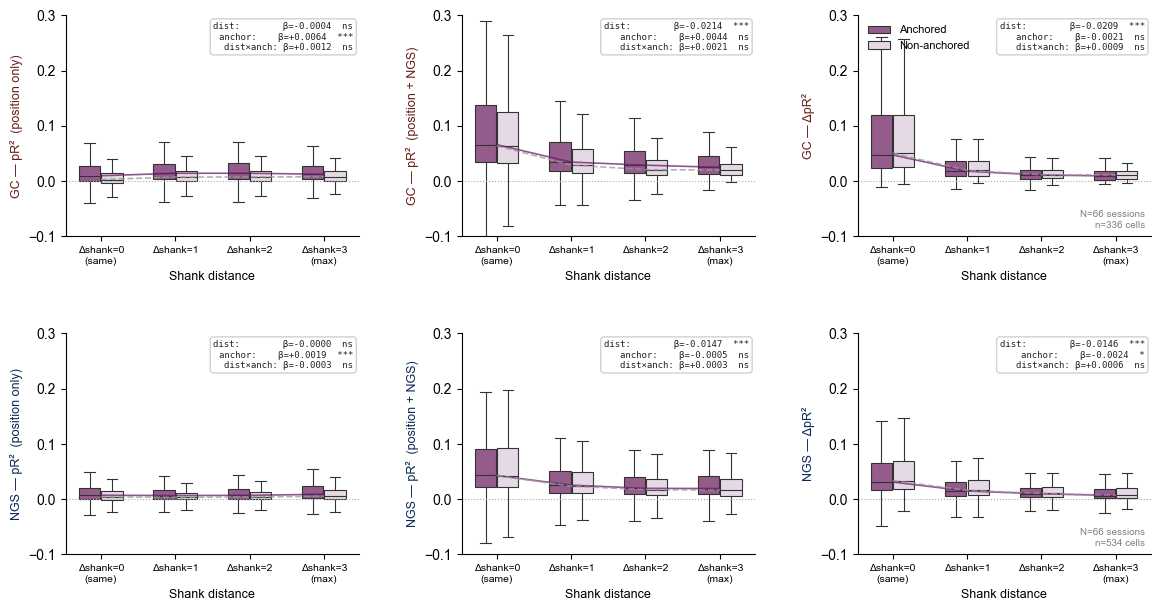

In [3]:
# ── Figure 1: pR²(pos), pR²(pos+NGS), ΔpR² — by shank distance × anchor mode ─
anchor_df['shank_distance'] = (
    anchor_df['target_shank_id'] - anchor_df['cov_shank_id']
).abs().astype(int)

anchor_palette = {'anchored': '#9d5391', 'non_anchored': '#e7d7e8'}
anchor_order   = ['anchored', 'non_anchored']
anchor_labels  = ['Anchored', 'Non-anchored']
dist_order     = [0, 1, 2, 3]
dist_labels    = ['Δshank=0\n(same)', 'Δshank=1', 'Δshank=2', 'Δshank=3\n(max)']

target_types  = ['GC', 'NG']
type_colors   = {'GC': gc_color, 'NG': ngs_color}
type_labels   = {'GC': 'GC', 'NG': 'NGS'}

metrics = [
    ('pR2_pos_cond', 'pR²  (position only)',  (-0.1, 0.3)),
    ('pR2_cond',     'pR²  (position + NGS)', (-0.1, 0.3)),
    ('delta_pR2',    'ΔpR²',                  (-0.1, 0.3)),
]

# ── LMM helpers ───────────────────────────────────────────────────────────────
def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _ps(p):
    return f'{p:.2e}' if p < 0.001 else f'{p:.3f}'

def _fit_lmm_shank(d, metric):
    _d = d[['mouse', 'session', 'shank_distance', 'anchor_mode', metric]].dropna().copy()
    _d['shank_distance'] = _d['shank_distance'].astype(float)
    try:
        md = smf.mixedlm(
            f"{metric} ~ shank_distance * C(anchor_mode, Treatment('non_anchored'))",
            data=_d,
            groups=_d['mouse'],
            vc_formula={'session': '0 + C(session)'},
        )
        mdf = md.fit(reml=True, method='lbfgs')
        anch_key = "C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
        int_key  = "shank_distance:C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
        return dict(
            b_dist=mdf.fe_params['shank_distance'],
            p_dist=mdf.pvalues['shank_distance'],
            b_anch=mdf.fe_params[anch_key],
            p_anch=mdf.pvalues[anch_key],
            b_int=mdf.fe_params[int_key],
            p_int=mdf.pvalues[int_key],
            ok=True,
        )
    except Exception as e:
        return dict(ok=False, error=str(e))

# ── Pre-fit all 6 LMMs ────────────────────────────────────────────────────────
lmm_res = {}
for ttype in target_types:
    d_fit = anchor_df[anchor_df['target_cell_type'] == ttype].copy()
    for metric, _, _ in metrics:
        print(f"  LMM: {ttype} / {metric} …", end=' ')
        lmm_res[(ttype, metric)] = _fit_lmm_shank(d_fit, metric)
        r = lmm_res[(ttype, metric)]
        if r['ok']:
            print(f"dist p={_ps(r['p_dist'])}, anchor p={_ps(r['p_anch'])}, "
                  f"interaction p={_ps(r['p_int'])}")
        else:
            print(f"FAILED: {r['error']}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(target_types), len(metrics),
    figsize=(14, 7),
    sharey=False,
)
fig.subplots_adjust(hspace=0.44, wspace=0.35)

for row, ttype in enumerate(target_types):
    d = anchor_df[anchor_df['target_cell_type'] == ttype].copy()
    short = type_labels[ttype]
    color = type_colors[ttype]

    for col, (metric, metric_label, ylim) in enumerate(metrics):
        ax = axes[row, col]

        sns.boxplot(
            data=d, x='shank_distance', y=metric,
            hue='anchor_mode', hue_order=anchor_order,
            order=dist_order, palette=anchor_palette,
            width=0.6, fliersize=0, linecolor='#333333',
            linewidth=0.8, gap=0.05, ax=ax,
        )

        # Median trend lines
        for am, ls in [('anchored', '-'), ('non_anchored', '--')]:
            medians = (
                d[d['anchor_mode'] == am]
                .groupby('shank_distance')[metric].median()
                .reindex(dist_order)
            )
            c = '#6a1f6a' if am == 'anchored' else '#999999'
            ax.plot(range(len(dist_order)), medians.values,
                    color=c, lw=1.2, ls=ls, alpha=0.75, zorder=5)

        # LMM annotation box — top right
        r = lmm_res[(ttype, metric)]
        ann = (
            f"dist:        β={r['b_dist']:+.4f}  {_sig(r['p_dist'])}\n"
            f"anchor:    β={r['b_anch']:+.4f}  {_sig(r['p_anch'])}\n"
            f"dist×anch: β={r['b_int']:+.4f}  {_sig(r['p_int'])}"
        ) if r['ok'] else 'LMM failed'
        ax.text(
            0.98, 0.97, ann, transform=ax.transAxes,
            fontsize=6.5, va='top', ha='right',
            fontfamily='monospace', color='#222',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor='#cccccc', alpha=0.90),
        )

        ax.axhline(0, color='#aaa', lw=0.8, ls=':')
        ax.set_xticks(range(len(dist_order)))
        ax.set_xticklabels(dist_labels, fontsize=7.5)
        ax.set_xlabel('Shank distance', fontsize=9)
        ax.set_ylabel(f'{short} — {metric_label}', fontsize=9, color=color)
        ax.set_ylim(ylim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # N / n counts — bottom right
        if col == len(metrics) - 1:
            N = d['session'].nunique()
            n = d['target_cluster_id'].nunique()
            ax.text(0.98, 0.03, f'N={N} sessions\nn={n} cells',
                    ha='right', va='bottom', color='grey', fontsize=7,
                    transform=ax.transAxes)

        if row == 0 and col == len(metrics) - 1:
            handles, _ = ax.get_legend_handles_labels()
            ax.legend(handles[:2], anchor_labels, fontsize=8,
                      frameon=False, loc='upper left')
        elif ax.get_legend():
            ax.get_legend().remove()

plt.savefig(fig_path + 'figure_anchor_delta_pr2_shankdist.pdf', dpi=300, bbox_inches='tight')
plt.show()


Pair-level filter (min_prop=0.4): 10082/29872 rows kept (33.8%), 502 unique cells
  LMM: GC / pR2_pos_cond … dist p=0.912, anchor p=0.006, interaction p=0.954
  LMM: GC / pR2_cond … dist p=7.12e-12, anchor p=0.277, interaction p=0.922
  LMM: GC / delta_pR2 … dist p=3.65e-15, anchor p=0.690, interaction p=0.883
  LMM: NG / pR2_pos_cond … dist p=0.407, anchor p=6.80e-06, interaction p=0.846
  LMM: NG / pR2_cond … dist p=1.57e-43, anchor p=0.202, interaction p=0.746
  LMM: NG / delta_pR2 … dist p=4.20e-52, anchor p=0.368, interaction p=0.792


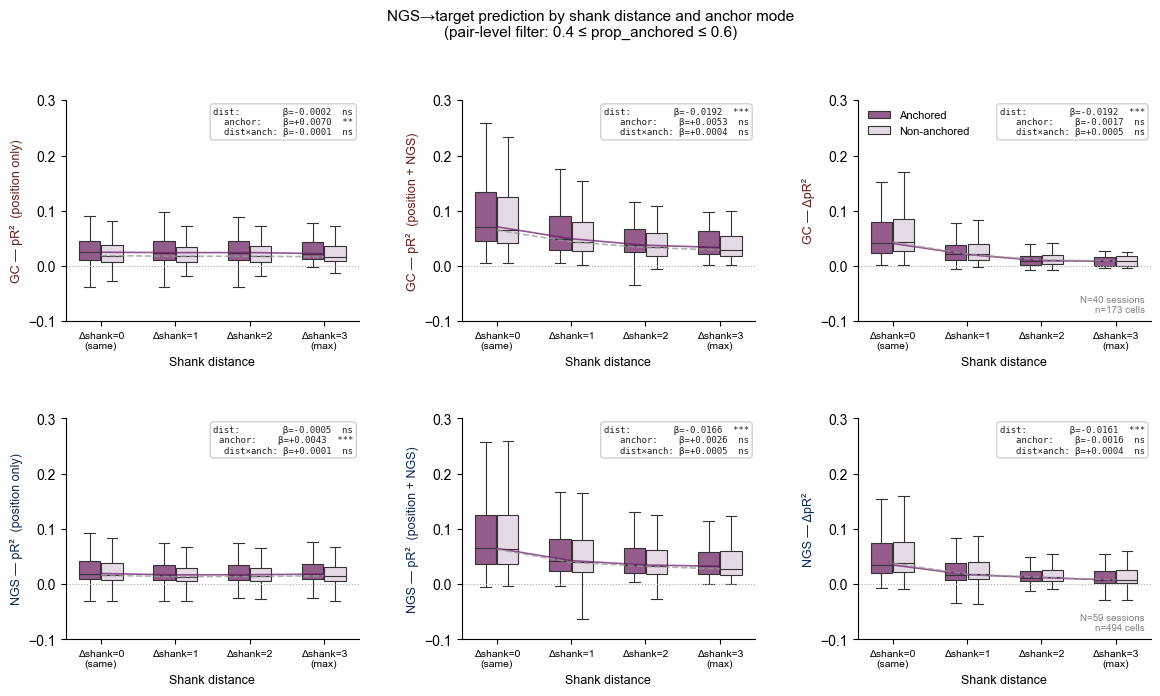

In [4]:
min_prop = 0.4

# ── Figure 1: pR²(pos), pR²(pos+NGS), ΔpR² — by shank distance × anchor mode ─
anchor_df['shank_distance'] = (
    anchor_df['target_shank_id'] - anchor_df['cov_shank_id']
).abs().astype(int)

anchor_palette = {'anchored': '#9d5391', 'non_anchored': '#e7d7e8'}
anchor_order   = ['anchored', 'non_anchored']
anchor_labels  = ['Anchored', 'Non-anchored']
dist_order     = [0, 1, 2, 3]
dist_labels    = ['Δshank=0\n(same)', 'Δshank=1', 'Δshank=2', 'Δshank=3\n(max)']

target_types = ['GC', 'NG']
type_colors  = {'GC': gc_color, 'NG': ngs_color}
type_labels  = {'GC': 'GC', 'NG': 'NGS'}

metrics = [
    ('pR2_pos_cond', 'pR²  (position only)',  (-0.1, 0.3)),
    ('pR2_cond',     'pR²  (position + NGS)', (-0.1, 0.3)),
    ('delta_pR2',    'ΔpR²',                  (-0.1, 0.3)),
]

# ── Pair-level filter ─────────────────────────────────────────────────────────
# Keep a cell-session-shank only if BOTH anchor modes are well-represented:
# min_prop <= prop_anchored <= 1 - min_prop.
# Non-anchored rows always pass row-level filters (prop ≈ 0.7-1.0), so we must
# filter on pairs — drop the whole pair if the anchored proportion is too extreme.
_anch_props = anchor_df[anchor_df['anchor_mode'] == 'anchored'].copy()
_valid_pairs = _anch_props[
    (_anch_props['prop_anchor_mode'] >= min_prop) &
    (_anch_props['prop_anchor_mode'] <= 1 - min_prop)
][['mouse', 'day', 'target_cluster_id', 'cov_shank_id']]

anchor_df_filtered = anchor_df.merge(
    _valid_pairs,
    on=['mouse', 'day', 'target_cluster_id', 'cov_shank_id'],
    how='inner',
).reset_index(drop=True)

n_orig = len(anchor_df)
n_kept = len(anchor_df_filtered)
print(f"Pair-level filter (min_prop={min_prop}): "
      f"{n_kept}/{n_orig} rows kept ({100*n_kept/n_orig:.1f}%), "
      f"{anchor_df_filtered['target_cluster_id'].nunique()} unique cells")

# ── LMM helpers ───────────────────────────────────────────────────────────────
def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _ps(p):
    return f'{p:.2e}' if p < 0.001 else f'{p:.3f}'

def _fit_lmm_shank(d, metric):
    _d = d[['mouse', 'session', 'shank_distance', 'anchor_mode',
            'prop_anchor_mode', metric]].dropna().copy()
    _d['shank_distance'] = _d['shank_distance'].astype(float)
    try:
        md = smf.mixedlm(
            f"{metric} ~ shank_distance * C(anchor_mode, Treatment('non_anchored'))"
            f" + prop_anchor_mode",
            data=_d,
            groups=_d['mouse'],
            vc_formula={'session': '0 + C(session)'},
        )
        mdf = md.fit(reml=True, method='lbfgs')
        anch_key = "C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
        int_key  = "shank_distance:C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
        return dict(
            b_dist=mdf.fe_params['shank_distance'],
            p_dist=mdf.pvalues['shank_distance'],
            b_anch=mdf.fe_params[anch_key],
            p_anch=mdf.pvalues[anch_key],
            b_int=mdf.fe_params[int_key],
            p_int=mdf.pvalues[int_key],
            ok=True,
        )
    except Exception as e:
        return dict(ok=False, error=str(e))

# ── Pre-fit all 6 LMMs ────────────────────────────────────────────────────────
lmm_res = {}
for ttype in target_types:
    d_fit = anchor_df_filtered[anchor_df_filtered['target_cell_type'] == ttype].copy()
    for metric, _, _ in metrics:
        print(f"  LMM: {ttype} / {metric} …", end=' ')
        lmm_res[(ttype, metric)] = _fit_lmm_shank(d_fit, metric)
        r = lmm_res[(ttype, metric)]
        if r['ok']:
            print(f"dist p={_ps(r['p_dist'])}, anchor p={_ps(r['p_anch'])}, "
                  f"interaction p={_ps(r['p_int'])}")
        else:
            print(f"FAILED: {r['error']}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(target_types), len(metrics),
    figsize=(14, 7),
    sharey=False,
)
fig.subplots_adjust(hspace=0.44, wspace=0.35)

for row, ttype in enumerate(target_types):
    d = anchor_df_filtered[anchor_df_filtered['target_cell_type'] == ttype].copy()
    short = type_labels[ttype]
    color = type_colors[ttype]

    for col, (metric, metric_label, ylim) in enumerate(metrics):
        ax = axes[row, col]

        sns.boxplot(
            data=d, x='shank_distance', y=metric,
            hue='anchor_mode', hue_order=anchor_order,
            order=dist_order, palette=anchor_palette,
            width=0.6, fliersize=0, linecolor='#333333',
            linewidth=0.8, gap=0.05, ax=ax,
        )

        # Median trend lines
        for am, ls in [('anchored', '-'), ('non_anchored', '--')]:
            medians = (
                d[d['anchor_mode'] == am]
                .groupby('shank_distance')[metric].median()
                .reindex(dist_order)
            )
            c = '#6a1f6a' if am == 'anchored' else '#999999'
            ax.plot(range(len(dist_order)), medians.values,
                    color=c, lw=1.2, ls=ls, alpha=0.75, zorder=5)

        # LMM annotation box — top right
        r = lmm_res[(ttype, metric)]
        ann = (
            f"dist:        β={r['b_dist']:+.4f}  {_sig(r['p_dist'])}\n"
            f"anchor:    β={r['b_anch']:+.4f}  {_sig(r['p_anch'])}\n"
            f"dist×anch: β={r['b_int']:+.4f}  {_sig(r['p_int'])}"
        ) if r['ok'] else 'LMM failed'
        ax.text(
            0.98, 0.97, ann, transform=ax.transAxes,
            fontsize=6.5, va='top', ha='right',
            fontfamily='monospace', color='#222',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor='#cccccc', alpha=0.90),
        )

        ax.axhline(0, color='#aaa', lw=0.8, ls=':')
        ax.set_xticks(range(len(dist_order)))
        ax.set_xticklabels(dist_labels, fontsize=7.5)
        ax.set_xlabel('Shank distance', fontsize=9)
        ax.set_ylabel(f'{short} — {metric_label}', fontsize=9, color=color)
        ax.set_ylim(ylim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if col == len(metrics) - 1:
            N = d['session'].nunique()
            n = d['target_cluster_id'].nunique()
            ax.text(0.98, 0.03, f'N={N} sessions\nn={n} cells',
                    ha='right', va='bottom', color='grey', fontsize=7,
                    transform=ax.transAxes)

        if row == 0 and col == len(metrics) - 1:
            handles, _ = ax.get_legend_handles_labels()
            ax.legend(handles[:2], anchor_labels, fontsize=8,
                      frameon=False, loc='upper left')
        elif ax.get_legend():
            ax.get_legend().remove()

plt.suptitle(
    f'NGS→target prediction by shank distance and anchor mode\n'
    f'(pair-level filter: {min_prop} ≤ prop_anchored ≤ {1-min_prop})',
    fontsize=11, y=1.01,
)
plt.savefig(fig_path + 'figure_anchor_delta_pr2_shankdist.pdf', dpi=300, bbox_inches='tight')
plt.show()


M26 D19 — Pair-level filter (min_prop=0.1): 1864/2080 rows kept (89.6%), 233 unique cells
  LMM: GC / pR2_pos_cond … dist p=0.828, anchor p=7.02e-05, interaction p=0.948
  LMM: GC / pR2_cond … dist p=3.87e-12, anchor p=0.239, interaction p=0.643
  LMM: GC / delta_pR2 … dist p=1.21e-13, anchor p=0.459, interaction p=0.639
  LMM: NG / pR2_pos_cond … dist p=0.765, anchor p=3.06e-05, interaction p=0.840
  LMM: NG / pR2_cond … dist p=1.52e-16, anchor p=0.134, interaction p=0.747
  LMM: NG / delta_pR2 … dist p=2.05e-20, anchor p=0.530, interaction p=0.630


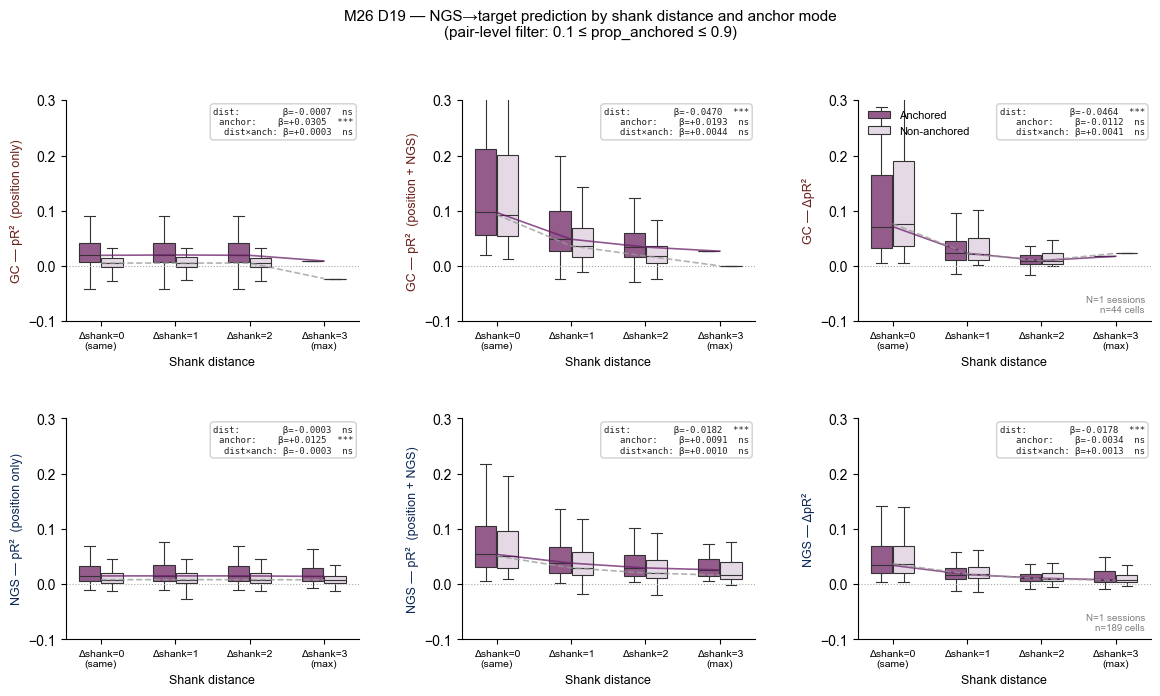

In [5]:
min_prop = 0.1

# ── Figure 1: pR²(pos), pR²(pos+NGS), ΔpR² — by shank distance × anchor mode ─
anchor_df['shank_distance'] = (
    anchor_df['target_shank_id'] - anchor_df['cov_shank_id']
).abs().astype(int)

anchor_palette = {'anchored': '#9d5391', 'non_anchored': '#e7d7e8'}
anchor_order   = ['anchored', 'non_anchored']
anchor_labels  = ['Anchored', 'Non-anchored']
dist_order     = [0, 1, 2, 3]
dist_labels    = ['Δshank=0\n(same)', 'Δshank=1', 'Δshank=2', 'Δshank=3\n(max)']

target_types = ['GC', 'NG']
type_colors  = {'GC': gc_color, 'NG': ngs_color}
type_labels  = {'GC': 'GC', 'NG': 'NGS'}

metrics = [
    ('pR2_pos_cond', 'pR²  (position only)',  (-0.1, 0.3)),
    ('pR2_cond',     'pR²  (position + NGS)', (-0.1, 0.3)),
    ('delta_pR2',    'ΔpR²',                  (-0.1, 0.3)),
]

# ── Subset to a single session ────────────────────────────────────────────────
anchor_df_sub = anchor_df[(anchor_df['mouse'] == 26) & (anchor_df['day'] == 19)].copy()

# ── Pair-level filter ─────────────────────────────────────────────────────────
_anch_props = anchor_df_sub[anchor_df_sub['anchor_mode'] == 'anchored'].copy()
_valid_pairs = _anch_props[
    (_anch_props['prop_anchor_mode'] >= min_prop) &
    (_anch_props['prop_anchor_mode'] <= 1 - min_prop)
][['mouse', 'day', 'target_cluster_id', 'cov_shank_id']]

anchor_df_filtered = anchor_df_sub.merge(
    _valid_pairs,
    on=['mouse', 'day', 'target_cluster_id', 'cov_shank_id'],
    how='inner',
).reset_index(drop=True)

n_orig = len(anchor_df_sub)
n_kept = len(anchor_df_filtered)
print(f"M26 D19 — Pair-level filter (min_prop={min_prop}): "
      f"{n_kept}/{n_orig} rows kept ({100*n_kept/n_orig:.1f}%), "
      f"{anchor_df_filtered['target_cluster_id'].nunique()} unique cells")

# ── LMM helpers ───────────────────────────────────────────────────────────────
def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _ps(p):
    return f'{p:.2e}' if p < 0.001 else f'{p:.3f}'

def _fit_lmm_shank(d, metric):
    _d = d[['mouse', 'session', 'shank_distance', 'anchor_mode',
            'prop_anchor_mode', metric]].dropna().copy()
    _d['shank_distance'] = _d['shank_distance'].astype(float)
    try:
        md = smf.mixedlm(
            f"{metric} ~ shank_distance * C(anchor_mode, Treatment('non_anchored'))"
            f" + prop_anchor_mode",
            data=_d,
            groups=_d['mouse'],
            vc_formula={'session': '0 + C(session)'},
        )
        mdf = md.fit(reml=True, method='lbfgs')
        anch_key = "C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
        int_key  = "shank_distance:C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
        return dict(
            b_dist=mdf.fe_params['shank_distance'],
            p_dist=mdf.pvalues['shank_distance'],
            b_anch=mdf.fe_params[anch_key],
            p_anch=mdf.pvalues[anch_key],
            b_int=mdf.fe_params[int_key],
            p_int=mdf.pvalues[int_key],
            ok=True,
        )
    except Exception as e:
        return dict(ok=False, error=str(e))

# ── Pre-fit all 6 LMMs ────────────────────────────────────────────────────────
# Note: single session → only one mouse group, so LMM random effects are
# degenerate. Results are indicative only; treat as descriptive stats.
lmm_res = {}
for ttype in target_types:
    d_fit = anchor_df_filtered[anchor_df_filtered['target_cell_type'] == ttype].copy()
    for metric, _, _ in metrics:
        print(f"  LMM: {ttype} / {metric} …", end=' ')
        lmm_res[(ttype, metric)] = _fit_lmm_shank(d_fit, metric)
        r = lmm_res[(ttype, metric)]
        if r['ok']:
            print(f"dist p={_ps(r['p_dist'])}, anchor p={_ps(r['p_anch'])}, "
                  f"interaction p={_ps(r['p_int'])}")
        else:
            print(f"FAILED: {r['error']}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(target_types), len(metrics),
    figsize=(14, 7),
    sharey=False,
)
fig.subplots_adjust(hspace=0.44, wspace=0.35)

for row, ttype in enumerate(target_types):
    d = anchor_df_filtered[anchor_df_filtered['target_cell_type'] == ttype].copy()
    short = type_labels[ttype]
    color = type_colors[ttype]

    for col, (metric, metric_label, ylim) in enumerate(metrics):
        ax = axes[row, col]

        sns.boxplot(
            data=d, x='shank_distance', y=metric,
            hue='anchor_mode', hue_order=anchor_order,
            order=dist_order, palette=anchor_palette,
            width=0.6, fliersize=0, linecolor='#333333',
            linewidth=0.8, gap=0.05, ax=ax,
        )

        # Median trend lines
        for am, ls in [('anchored', '-'), ('non_anchored', '--')]:
            medians = (
                d[d['anchor_mode'] == am]
                .groupby('shank_distance')[metric].median()
                .reindex(dist_order)
            )
            c = '#6a1f6a' if am == 'anchored' else '#999999'
            ax.plot(range(len(dist_order)), medians.values,
                    color=c, lw=1.2, ls=ls, alpha=0.75, zorder=5)

        # LMM annotation box — top right
        r = lmm_res[(ttype, metric)]
        ann = (
            f"dist:        β={r['b_dist']:+.4f}  {_sig(r['p_dist'])}\n"
            f"anchor:    β={r['b_anch']:+.4f}  {_sig(r['p_anch'])}\n"
            f"dist×anch: β={r['b_int']:+.4f}  {_sig(r['p_int'])}"
        ) if r['ok'] else 'LMM failed'
        ax.text(
            0.98, 0.97, ann, transform=ax.transAxes,
            fontsize=6.5, va='top', ha='right',
            fontfamily='monospace', color='#222',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor='#cccccc', alpha=0.90),
        )

        ax.axhline(0, color='#aaa', lw=0.8, ls=':')
        ax.set_xticks(range(len(dist_order)))
        ax.set_xticklabels(dist_labels, fontsize=7.5)
        ax.set_xlabel('Shank distance', fontsize=9)
        ax.set_ylabel(f'{short} — {metric_label}', fontsize=9, color=color)
        ax.set_ylim(ylim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if col == len(metrics) - 1:
            N = d['session'].nunique()
            n = d['target_cluster_id'].nunique()
            ax.text(0.98, 0.03, f'N={N} sessions\nn={n} cells',
                    ha='right', va='bottom', color='grey', fontsize=7,
                    transform=ax.transAxes)

        if row == 0 and col == len(metrics) - 1:
            handles, _ = ax.get_legend_handles_labels()
            ax.legend(handles[:2], anchor_labels, fontsize=8,
                      frameon=False, loc='upper left')
        elif ax.get_legend():
            ax.get_legend().remove()

plt.suptitle(
    f'M26 D19 — NGS→target prediction by shank distance and anchor mode\n'
    f'(pair-level filter: {min_prop} ≤ prop_anchored ≤ {1-min_prop})',
    fontsize=11, y=1.01,
)
plt.savefig(fig_path + 'figure_anchor_delta_pr2_shankdist_M26D19.pdf', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation — Figure 1**

Each panel shows a metric (pR² position-only | pR² position+NGS | ΔpR²) as a function of **shank distance** between the target cell and its NGS covariate pool (0 = same shank, 3 = maximum separation). Purple boxes = anchored trials; light boxes = non-anchored. Solid and dashed trend lines connect the medians for each state.

**Three LMM fixed effects are annotated in every panel** (model: `metric ~ shank_distance * anchor_mode`, mouse random intercept, session variance component):

| Term | What it tests |
|---|---|
| `dist` | Does prediction change with shank separation, regardless of anchoring state? |
| `anchor` | Is there a main effect of anchoring state at Δshank = 0 (the reference distance)? |
| `dist×anch` | Does the *rate of decay with distance* differ between anchored and non-anchored trials? |

**What to look for:**

- **pR² (position only):** Should not vary with shank distance — this column is a sanity check. A significant `dist` term here would flag a confound.
- **pR² (position + NGS) and ΔpR²:** A significant negative `dist` coefficient confirms that nearby NGS cells are better predictors than distant ones — the spatially localised co-activity effect. A significant `anchor` term would mean the overall level of NGS predictive power shifts with anchoring state. A significant `dist×anchor` interaction would mean the *spatial fall-off of coupling* is steeper or shallower during anchored vs non-anchored trials — the most direct test of whether anchoring reorganises the spatial structure of NGS–target coupling.


**Interpretation — Figure 2**

This figure asks whether any anchor-mode effect is concentrated in the NGS cells on the same probe shank as the GC target. Shanks run medial→lateral, so same-shank NGS cells are anatomically proximal and likely to share more local circuit input.

The two panels show GC ΔpR² split into same-shank (left) and different-shank (right) covariate pools. Comparing the overall ΔpR² levels between panels is informative in itself: same-shank NGS cells typically explain considerably more GC variance than cross-shank cells, consistent with a spatially localised influence. The anchored vs non-anchored split within each panel then tests whether this local (or distal) influence is modulated by the GC's anchoring state.

If the anchor-mode effect were present only in the same-shank panel, it would suggest the mechanism is local — anchored GCs and their nearby NGS neighbours share a common state that makes their activity more tightly coupled. A null result in both panels would indicate that NGS predictive power is independent of the GC's current anchoring state.


**Interpretation — LMM results**

The four mixed models test whether anchored trials show higher ΔpR² than non-anchored trials, accounting for the nested structure (sessions within mice).

**GC targets (all shanks):** β = −0.00136, p = 0.488 — no significant effect. NGS cells predict GC firing equally well regardless of whether the GC is in an anchored or non-anchored state.

**GC targets (same-shank only):** β = −0.00220, p = 0.538 — again no significant effect. Even restricting to the most proximal NGS covariate pool, anchoring state does not modulate how well NGS cells predict GC activity.

**NGS targets (all shanks):** β = −0.00188, p = 0.012 — a small but significant effect, and notably in the *negative* direction. NGS cells are slightly *less* predictable from other NGS cells during anchored trials than during non-anchored trials. This is the opposite of the hypothesised direction.

**NGS targets (same-shank only):** β = −0.00251, p = 0.077 — a marginal trend in the same negative direction, falling short of the conventional threshold.

**Overall:** The data do not support the hypothesis that task anchoring increases NGS→target predictive coupling. For GCs the effect is null. For NGS targets the weak effect runs counter to prediction, suggesting that NGS cells may be *more* decorrelated from one another during anchored states, not less.


**Interpretation — Figure 3**

This forest plot summarises all four LMM fixed-effect estimates on a common axis. Each point is β_anchored (anchored − non-anchored ΔpR²) with 95% confidence intervals. The dashed line at zero is the null hypothesis.

All four estimates sit near or slightly left of zero, with only the NGS all-shanks model crossing the significance threshold (p = 0.012) — and in the negative direction. The CIs for both GC models comfortably span zero, confirming the null result for the main hypothesis.

**Summary:** Task anchoring state, as derived from each cell's own spectral tuning, does not detectably modulate NGS→GC predictive coupling. The small negative trend in NGS→NGS coupling during anchored trials is an interesting secondary finding but was not the primary prediction, and its effect size (β ≈ −0.002) is modest relative to the baseline ΔpR² (~0.06). This pattern could reflect that anchored NGS cells become more strongly driven by position (reducing the residual shared variance beyond position that XGBoost can exploit), or simply that anchored trial epochs are shorter and noisier for estimating conditional pR².


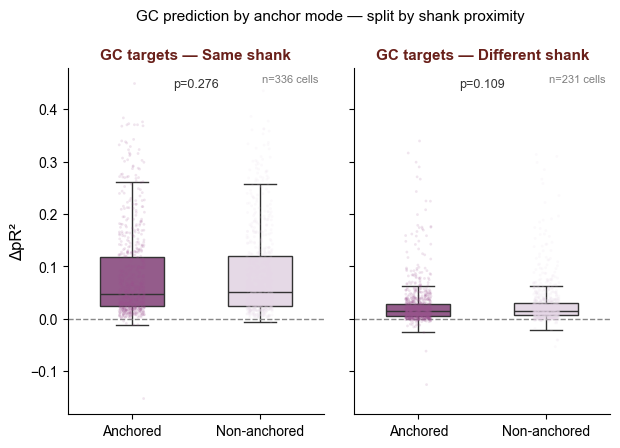

In [6]:

# ── Figure 2: ΔpR² by anchor mode × same/different shank (GC targets only) ──
shank_labels_map = {True: 'Same shank', False: 'Different shank'}

d_gc = anchor_df[anchor_df['target_cell_type'] == 'GC'].copy()

fig, axes = plt.subplots(1, 2, figsize=(7, 4.5), sharey=True)
fig.subplots_adjust(wspace=0.12)

for ax, shank_flag in zip(axes, [True, False]):
    d = d_gc[d_gc['same_shank'] == shank_flag].copy()

    sns.boxplot(
        data=d, x='anchor_mode', y='delta_pR2',
        order=anchor_order,
        palette=anchor_palette,
        width=0.5, fliersize=0, linecolor='#333333', ax=ax,
    )
    sns.stripplot(
        data=d, x='anchor_mode', y='delta_pR2',
        order=anchor_order,
        palette=anchor_palette,
        alpha=0.15, jitter=True, size=2.0, ax=ax,
    )

    _anch = d[d['anchor_mode'] == 'anchored']['delta_pR2'].dropna()
    _nonanch = d[d['anchor_mode'] == 'non_anchored']['delta_pR2'].dropna()
    if len(_anch) > 1 and len(_nonanch) > 1:
        _, _p = stats.mannwhitneyu(_anch, _nonanch, alternative='two-sided')
        _pstr = f'p={_p:.2e}' if _p < 0.001 else f'p={_p:.3f}'
        ax.text(0.5, 0.97, _pstr, ha='center', va='top', fontsize=9,
                color='#333', transform=ax.transAxes)

    ax.axhline(0, color='#888', lw=1, ls='--')
    ax.set_xticklabels(anchor_labels, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('ΔpR²' if ax is axes[0] else '', fontsize=12)
    ax.set_title(f'GC targets — {shank_labels_map[shank_flag]}', fontsize=11,
                 fontweight='bold', color=gc_color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    n = d['target_cluster_id'].nunique()
    ax.text(0.98, 0.98, f'n={n} cells', ha='right', va='top',
            color='grey', fontsize=8, transform=ax.transAxes)

plt.suptitle('GC prediction by anchor mode — split by shank proximity', fontsize=11, y=1.01)
plt.savefig(fig_path + 'figure_anchor_delta_pr2_shank_split.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [7]:

def run_anchor_lmm(cell_type_label, same_shank_only=False):
    """
    LMM: delta_pR2 ~ C(anchor_mode) with mouse random intercept
    and session-level variance component. Reference level = 'non_anchored'.
    """
    d = anchor_df[anchor_df['target_cell_type'] == cell_type_label].copy()
    if same_shank_only:
        d = d[d['same_shank'] == True].copy()
    d = d.dropna(subset=['delta_pR2', 'anchor_mode', 'mouse', 'session'])

    md  = smf.mixedlm(
        "delta_pR2 ~ C(anchor_mode, Treatment('non_anchored'))",
        data=d,
        groups=d['mouse'],
        vc_formula={'session': '0 + C(session)'},
    )
    mdf = md.fit(reml=True, method='lbfgs')

    coef_key = "C(anchor_mode, Treatment('non_anchored'))[T.anchored]"
    coef = mdf.fe_params[coef_key]
    se   = mdf.bse[coef_key]
    pval = mdf.pvalues[coef_key]
    pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'

    label = f"{cell_type_label}" + (" (same-shank only)" if same_shank_only else "")
    print(f"\n{'='*60}")
    print(f"LMM — {label}")
    print(f"  anchored − non_anchored: β={coef:.5f}, SE={se:.5f}, {pstr}")
    print(mdf.summary())
    return mdf

# All NGS covariate pools
lmm_gc_all   = run_anchor_lmm('GC', same_shank_only=False)
lmm_gc_same  = run_anchor_lmm('GC', same_shank_only=True)
lmm_ngs_all  = run_anchor_lmm('NG', same_shank_only=False)
lmm_ngs_same = run_anchor_lmm('NG', same_shank_only=True)



LMM — GC
  anchored − non_anchored: β=-0.00136, SE=0.00196, p=0.488
                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              delta_pR2
No. Observations:                3111                 Method:                          REML     
No. Groups:                      8                    Scale:                           0.0030   
Min. group size:                 46                   Log-Likelihood:                  4511.5901
Max. group size:                 645                  Converged:                       Yes      
Mean group size:                 388.9                                                          
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------

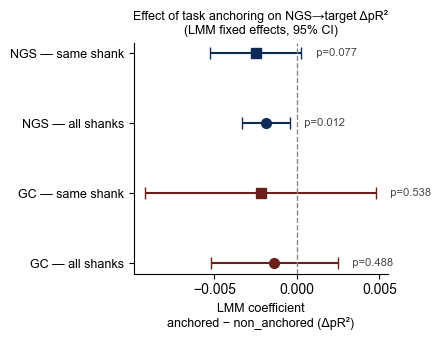

In [8]:

# ── Visualise LMM fixed-effect estimates (anchored − non_anchored) with 95% CI ──
coef_key = "C(anchor_mode, Treatment('non_anchored'))[T.anchored]"

results_summary = []
for lmm, label in [
    (lmm_gc_all,   'GC — all shanks'),
    (lmm_gc_same,  'GC — same shank'),
    (lmm_ngs_all,  'NGS — all shanks'),
    (lmm_ngs_same, 'NGS — same shank'),
]:
    coef = lmm.fe_params[coef_key]
    se   = lmm.bse[coef_key]
    pval = lmm.pvalues[coef_key]
    results_summary.append(dict(label=label, coef=coef, se=se, pval=pval))

coef_df = pd.DataFrame(results_summary)
coef_df['ci_lo'] = coef_df['coef'] - 1.96 * coef_df['se']
coef_df['ci_hi'] = coef_df['coef'] + 1.96 * coef_df['se']

colors_coef = [gc_color, gc_color, ngs_color, ngs_color]
markers_coef = ['o', 's', 'o', 's']

fig, ax = plt.subplots(figsize=(4.5, 3.5))
for i, (_, row) in enumerate(coef_df.iterrows()):
    ax.errorbar(
        row['coef'], i,
        xerr=[[row['coef'] - row['ci_lo']], [row['ci_hi'] - row['coef']]],
        fmt=markers_coef[i], color=colors_coef[i],
        markersize=7, capsize=4, lw=1.5,
    )
    pstr = f"p={row['pval']:.2e}" if row['pval'] < 0.001 else f"p={row['pval']:.3f}"
    ax.text(row['ci_hi'] + 0.0005, i, f'  {pstr}', va='center', fontsize=8, color='#444')

ax.axvline(0, color='#888', lw=1, ls='--')
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['label'], fontsize=9)
ax.set_xlabel('LMM coefficient\nanchored − non_anchored (ΔpR²)', fontsize=9)
ax.set_title('Effect of task anchoring on NGS→target ΔpR²\n(LMM fixed effects, 95% CI)', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(fig_path + 'figure_anchor_lmm_coefficients.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import pynapple as nap
from scipy.ndimage import gaussian_filter
from spatial_manifolds.mlencoding import *
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')

MOUSE           = 26
DAY             = 19
SOURCE_PATH     = '/Users/harryclark/Downloads/COHORT12/'
cell_class_path = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'
PEAK_INDICES    = [12, 28, 44, 60, 76]
MIN_ANCHOR_BINS = 10
CELLS_PER_PAGE  = 4

# ── Load session ───────────────────────────────────────────────────────────────
print("Loading M26 D19...")
tcs_sess, tcs_time_sess, _, last_ephys_bin_sess, beh_sess, clusters_sess = compute_vr_tcs(
    MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False, source_path=SOURCE_PATH
)
last_ephys_time_bin = clusters_sess[clusters_sess.index[0]].count(
    bin_size=time_bs, time_units='ms'
).index[-1]
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

dt_in_time = np.array(
    beh_sess['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
    - ((beh_sess['trial_number'][0] - 1) * tl)
)
pos_in_time = dt_in_time % tl
if np.any(np.isnan(pos_in_time)):
    pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl
trial_number_in_time = (dt_in_time // tl) + beh_sess['trial_number'][0]
first_trial = int(beh_sess['trial_number'][0])
print(f"  T={len(pos_in_time)} time bins, {last_ephys_bin_sess} trial bins, first_trial={first_trial}")

# ── Cell metadata ──────────────────────────────────────────────────────────────
cell_classifications = pd.read_csv(cell_class_path)
sess_cells = cell_classifications[
    (cell_classifications['mouse'] == MOUSE) &
    (cell_classifications['day']   == DAY) &
    (cell_classifications['cell_type'].isin(['GC', 'NG']))
].copy()
sess_cells['cluster_id'] = sess_cells['cluster_id'].astype(int)
sess_cells = reconstruct_shank_id(sess_cells, MOUSE, colname='probe_x')
cell_shank_map = dict(zip(sess_cells['cluster_id'], sess_cells['shank_id']))
cell_type_map  = dict(zip(sess_cells['cluster_id'], sess_cells['cell_type']))

all_shanks = sorted(sess_cells['shank_id'].unique())
ngs_by_shank = {
    sh: grp['cluster_id'].values.astype(int)
    for sh, grp in sess_cells[sess_cells['cell_type'] == 'NG'].groupby('shank_id')
    if any(c in tcs_time_sess for c in grp['cluster_id'].astype(int))
}
print(f"  Shanks: {all_shanks}")
print(f"  {(sess_cells['cell_type']=='GC').sum()} GC target cells, "
      f"{(sess_cells['cell_type']=='NG').sum()} NG covariate cells")

# ── XGBoost ────────────────────────────────────────────────────────────────────
xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                 window=time_bs, n_filters=5, max_time=1000)

# ── Conditions ────────────────────────────────────────────────────────────────
cond_names = (
    ['pos'] +
    [f'pos_ngs_sh{s}' for s in all_shanks] +
    [f'ngs_sh{s}'     for s in all_shanks]
)
col_labels = (
    ['Actual', 'Pos-only'] +
    [f'Pos+NGS sh{s}' for s in all_shanks] +
    [f'NGS only sh{s}' for s in all_shanks]
)
col_keys = (
    ['actual', 'pos'] +
    [f'pos_ngs_sh{s}' for s in all_shanks] +
    [f'ngs_sh{s}'     for s in all_shanks]
)

# ── Helpers ────────────────────────────────────────────────────────────────────
def _get_labels(target_id):
    if target_id not in tcs_sess:
        return None
    tc_raw = gaussian_filter(np.nan_to_num(tcs_sess[target_id]).astype(np.float64), sigma=2.5)
    tc_raw = tc_raw[:last_ephys_bin_sess]
    results = spectral_analysis({target_id: tc_raw, 1000: tc_raw}, tl, bs=bs)
    S = results[3].mean(0)
    labels_idx = np.isin(np.argmax(S, axis=0), PEAK_INDICES).astype(int)
    return get_kmeans_spatial_labels(tc_raw, labels_idx, bs=bs, tl=tl)

def _labels_to_time(labels, T):
    out = np.zeros(T, dtype=int)
    for ti, tn in enumerate(trial_number_in_time[:T].astype(int)):
        idx = tn - first_trial
        if 0 <= idx < len(labels):
            out[ti] = int(labels[idx])
    return out

def _cond_pr2(y, yhat, mask):
    if mask.sum() < MIN_ANCHOR_BINS:
        return np.nan
    mu = np.nanmean(y[mask])
    return float(poisson_pseudoR2(y[mask], yhat[mask], mu))

# ── Phase 1: Fit all conditions — GC targets only ─────────────────────────────
results_rows = []
yhats_store  = {}
labels_store = {}

all_ids = (
    sess_cells[sess_cells['cell_type'] == 'GC']
    .sort_values(['shank_id', 'cluster_id'])['cluster_id'].values
)
n_total = len(all_ids)
print(f"\nFitting {n_total} GC target cells...")

for idx, target_id in enumerate(all_ids):
    target_id    = int(target_id)
    if target_id not in tcs_time_sess:
        continue
    target_shank = cell_shank_map[target_id]

    labels = _get_labels(target_id)
    if labels is None:
        print(f"[{idx+1}/{n_total}] GC {target_id}: labelling failed, skip")
        continue

    y   = np.array(tcs_time_sess[target_id])
    T   = len(y)
    pos = pos_in_time[:T]
    if len(pos) < T:
        pos = np.pad(pos, (0, T - len(pos)), mode='edge')

    tl_t         = _labels_to_time(labels, T)
    anch_mask    = tl_t == 1
    nonanch_mask = tl_t == 0
    prop_anch    = anch_mask.sum() / T

    print(f"[{idx+1}/{n_total}] GC {target_id} sh{target_shank} "
          f"p_anch={prop_anch:.3f}", end='  ')

    # pos-only
    Y_pos, _ = xgb.fit_cv(pos[:, None], y, verbose=0, continuous_folds=True)
    yhats_store[(target_id, 'pos')] = Y_pos
    pR2_pos_anch    = _cond_pr2(y, Y_pos, anch_mask)
    pR2_pos_nonanch = _cond_pr2(y, Y_pos, nonanch_mask)

    # per-shank: pos+NGS and NGS-only
    for cov_shank in all_shanks:
        valid_ngs    = [c for c in ngs_by_shank.get(cov_shank, [])
                        if c in tcs_time_sess and c != target_id]
        pos_ngs_key  = f'pos_ngs_sh{cov_shank}'
        ngs_only_key = f'ngs_sh{cov_shank}'

        if valid_ngs:
            ngs_mat = np.vstack([
                np.pad(np.array(tcs_time_sess[c])[:T],
                       (0, max(0, T - len(np.array(tcs_time_sess[c])[:T]))),
                       mode='constant')
                for c in valid_ngs
            ]).T
            Y_pos_ngs,  _ = xgb.fit_cv(np.column_stack([pos, ngs_mat]), y,
                                        verbose=0, continuous_folds=True)
            Y_ngs_only, _ = xgb.fit_cv(ngs_mat, y,
                                        verbose=0, continuous_folds=True)
        else:
            Y_pos_ngs  = Y_pos.copy()
            Y_ngs_only = Y_pos.copy()

        yhats_store[(target_id, pos_ngs_key)]  = Y_pos_ngs
        yhats_store[(target_id, ngs_only_key)] = Y_ngs_only

        pR2_posngs_anch     = _cond_pr2(y, Y_pos_ngs,  anch_mask)
        pR2_posngs_nonanch  = _cond_pr2(y, Y_pos_ngs,  nonanch_mask)
        pR2_ngsonly_anch    = _cond_pr2(y, Y_ngs_only, anch_mask)
        pR2_ngsonly_nonanch = _cond_pr2(y, Y_ngs_only, nonanch_mask)

        for anchor_name, pR2_posngs, pR2_ngsonly, pR2_pos_this in [
            ('anchored',     pR2_posngs_anch,    pR2_ngsonly_anch,    pR2_pos_anch),
            ('non_anchored', pR2_posngs_nonanch, pR2_ngsonly_nonanch, pR2_pos_nonanch),
        ]:
            results_rows.append(dict(
                mouse=MOUSE, day=DAY,
                target_cluster_id=target_id,
                target_shank_id=target_shank,
                target_cell_type='GC',
                cov_shank_id=cov_shank,
                n_ngs_cells=len(valid_ngs),
                anchor_mode=anchor_name,
                prop_anchor_mode=prop_anch,
                pR2_pos_cond=pR2_pos_this,
                pR2_cond=pR2_posngs,
                pR2_ngs_only_cond=pR2_ngsonly,
                delta_pR2=(pR2_posngs - pR2_pos_this
                           if not (np.isnan(pR2_posngs) or np.isnan(pR2_pos_this))
                           else np.nan),
                delta_pR2_ngs_only=(pR2_ngsonly - pR2_pos_this
                                    if not (np.isnan(pR2_ngsonly) or np.isnan(pR2_pos_this))
                                    else np.nan),
            ))

    labels_store[target_id] = labels
    print("done")

results_df = pd.DataFrame(results_rows)
results_df['shank_distance'] = (
    results_df['target_shank_id'] - results_df['cov_shank_id']
).abs().astype(int)
print(f"\nResults: {len(results_df)} rows, "
      f"{results_df['target_cluster_id'].nunique()} GC cells")
display(results_df.head(12))

# ── Phase 2: Batch convert Y_hat → trial×pos rate maps ────────────────────────
print("\nConverting Y_hat → trial×position rate maps...")
tcs_recon = {}

for cond in cond_names:
    yhats_this = {
        cid: yhats_store[(cid, cond)]
        for cid in labels_store
        if (cid, cond) in yhats_store
    }
    tc_out, _, _, _, _, _ = compute_vr_tcs_using_expected_spikes(
        MOUSE, DAY,
        apply_zscore=False, apply_guassian_filter=False,
        vr_type='VR', source_path=SOURCE_PATH,
        expected_spikes=yhats_this,
    )
    tcs_recon[cond] = tc_out
    print(f"  {cond}: done ({len(tc_out)} cells)")

# ── Phase 3: Multi-page PDF ───────────────────────────────────────────────────
fitted_ids = list(labels_store.keys())
n_cells    = len(fitted_ids)
n_pages    = int(np.ceil(n_cells / CELLS_PER_PAGE))
n_cols     = len(col_keys)
pdf_path   = fig_path + f'M{MOUSE}D{DAY}_GC_ratemaps_diagnostic.pdf'
print(f"\nWriting PDF: {n_pages} pages, {n_cells} GC cells, "
      f"{n_cols} columns each → {pdf_path}")

with PdfPages(pdf_path) as pdf:
    for page in range(n_pages):
        page_cells = fitted_ids[page * CELLS_PER_PAGE : (page + 1) * CELLS_PER_PAGE]
        n_this = len(page_cells)

        fig = plt.figure(figsize=(2.2 * n_cols, 3.6 * n_this))
        outer = GridSpec(n_this, 1, figure=fig, hspace=0.65)

        for ci, target_id in enumerate(page_cells):
            shank     = cell_shank_map.get(target_id, '?')
            labels    = labels_store[target_id]
            prop_anch = sum(labels) / len(labels)

            inner = GridSpecFromSubplotSpec(1, n_cols, subplot_spec=outer[ci], wspace=0.28)

            for col_i, (col_lbl, col_key) in enumerate(zip(col_labels, col_keys)):
                col_gs = GridSpecFromSubplotSpec(
                    2, 1, subplot_spec=inner[col_i],
                    height_ratios=[0.45, 1], hspace=0.08
                )
                ax_avg = fig.add_subplot(col_gs[0])
                ax_rm  = fig.add_subplot(col_gs[1])

                if col_key == 'actual':
                    tc_raw = tcs_sess.get(target_id)
                else:
                    tc_raw = tcs_recon.get(col_key, {}).get(target_id)

                if tc_raw is not None:
                    tc = gaussian_filter(
                        np.nan_to_num(tc_raw).astype(np.float64), sigma=2.5
                    )[:last_ephys_bin_sess]
                    n_rows      = min(tc.shape[0], len(labels))
                    tc_plot     = tc[:n_rows]
                    lbl_aligned = labels[:n_rows]

                    for lval, lcol in [(True, 'magenta'), (False, 'cyan')]:
                        mask = lbl_aligned == lval
                        if mask.sum() > 5:
                            x_p, y_p = get_avg_profile(tc_plot, bs, tl, mask=mask)
                            ax_avg.plot(x_p, y_p, color=lcol, lw=1.5)

                    if col_key == 'pos':
                        r_ref = results_df[
                            (results_df['target_cluster_id'] == target_id) &
                            (results_df['cov_shank_id'] == shank)
                        ]
                        for am, am_col, ya in [('anchored','magenta',0.99),
                                               ('non_anchored','cyan',0.75)]:
                            rv = r_ref[r_ref['anchor_mode'] == am]['pR2_pos_cond']
                            if len(rv):
                                ax_avg.text(0.99, ya, f'pR²={rv.values[0]:.3f}',
                                            transform=ax_avg.transAxes, fontsize=5,
                                            ha='right', va='top', color=am_col)

                    elif col_key != 'actual':
                        is_ngs_only = col_key.startswith('ngs_sh')
                        cov_sh  = int(col_key.split('sh')[1])
                        r_ref   = results_df[
                            (results_df['target_cluster_id'] == target_id) &
                            (results_df['cov_shank_id'] == cov_sh)
                        ]
                        pr2_col  = 'pR2_ngs_only_cond' if is_ngs_only else 'pR2_cond'
                        delt_col = 'delta_pR2_ngs_only' if is_ngs_only else 'delta_pR2'
                        for am, am_col, ya in [('anchored','magenta',0.99),
                                               ('non_anchored','cyan',0.75)]:
                            r_am = r_ref[r_ref['anchor_mode'] == am]
                            if len(r_am):
                                ax_avg.text(
                                    0.99, ya,
                                    f'pR²={r_am[pr2_col].values[0]:.3f}  '
                                    f'Δ={r_am[delt_col].values[0]:+.3f}',
                                    transform=ax_avg.transAxes, fontsize=5,
                                    ha='right', va='top', color=am_col,
                                )

                    plot_firing_rate_map(
                        ax_rm, tc_plot, bs=bs, tl=tl, p=95,
                        sort_indices=None, cmap=white_to_hex_cmap(gc_color),
                    )
                    for ti, lbl in enumerate(lbl_aligned):
                        ax_rm.scatter(tl * 1.03, ti,
                                      color='magenta' if lbl else 'cyan',
                                      s=2, marker='s', clip_on=False)

                ax_avg.set_xticks([])
                ax_avg.yaxis.set_major_locator(plt.MaxNLocator(2, integer=True))
                ax_avg.tick_params(labelsize=5)
                ax_avg.spines['top'].set_visible(False)
                ax_avg.spines['right'].set_visible(False)
                ax_avg.set_title(col_lbl, fontsize=6, pad=2)
                ax_rm.set_xlabel('Pos (cm)', fontsize=5)
                ax_rm.tick_params(labelsize=4)

                if col_i == 0:
                    ax_rm.set_ylabel(
                        f'GC {target_id}  sh{shank}\np_anch={prop_anch:.2f}',
                        fontsize=6, color=gc_color,
                    )
                if ci == 0 and col_i == 0:
                    from matplotlib.lines import Line2D
                    ax_avg.legend(
                        handles=[Line2D([0],[0],color='magenta',lw=1.5),
                                 Line2D([0],[0],color='cyan',lw=1.5)],
                        labels=['anchored','non-anch'],
                        fontsize=5, frameon=False, loc='upper right',
                    )

        fig.suptitle(
            f'M{MOUSE} D{DAY} GC targets — Actual vs XGBoost Reconstructed Rate Maps  '
            f'(page {page+1}/{n_pages})\n'
            f'Magenta=anchored  Cyan=non-anchored  '
            f'Annotations: pR² and Δ=delta_pR² vs pos-only baseline',
            fontsize=7, y=1.01,
        )
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        print(f"  page {page+1}/{n_pages}")

print(f"Saved → {pdf_path}")


Loading M26 D19...
  T=182843 time bins, 33200 trial bins, first_trial=17
  Shanks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  47 GC target cells, 213 NG covariate cells

Fitting 47 GC target cells...
[1/47] GC 24 sh0 p_anch=0.293  done
[2/47] GC 113 sh1 p_anch=0.373  done
[3/47] GC 114 sh1 p_anch=0.461  

KeyboardInterrupt: 